In [4]:
import numpy as np
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [5]:
## System parameters
M = 64 #Number of BS antennas
P = 1 #Power
K =  2 #Number of users
L = 8 #Number of pilots
Lp = [2,3,4,5,6,7,8]
B = 30 #Number of feedback bits per user

## Limited scattering channel parameters
LSF_UE = np.array([0.0,0.0],dtype=np.float32) #Mean of path gains for K users
Mainlobe_UE= np.array([0,0],dtype=np.float32) #Center of the AoD range for K users
HalfBW_UE = np.array([30.0,30.0],dtype=np.float32) #Half of the AoD range for K users

# SNR
snr_dl = 10 #SNR in dB
noise_std_dl = np.float32(np.sqrt(1/2)*np.sqrt(P/10**(snr_dl/10))) #STD of the Gaussian noise (per real dim.)

# Number of Monte-Carlo similations -> batch_size = N_experiment
iter = 10000

### Batch data 생성 함수

In [3]:
## 리스트 인덱싱은 [층, 행, 열], [행, 열]임!
def generate_batch_data(batch_size,M,K,
                        Lp,#number of paths
                        LSF_UE #Mean of path gains for K users
                        ,Mainlobe_UE #Center of the AoD range for K users
                        ,HalfBW_UE #Half of the AoD range for K users
                        ):
    alphaR_input = np.zeros((batch_size,Lp,K))
    alphaI_input = np.zeros((batch_size,Lp,K))
    theta_input = np.zeros((batch_size,Lp,K))
    for kk in range(K): # for the number of users
        alphaR_input[:,:,kk] = np.random.normal(loc=LSF_UE[kk], scale=1.0/np.sqrt(2), size=[batch_size,Lp])
        alphaI_input[:,:,kk] = np.random.normal(loc=LSF_UE[kk], scale=1.0/np.sqrt(2), size=[batch_size,Lp])
        theta_input[:,:,kk] = np.random.uniform(low=Mainlobe_UE[kk]-HalfBW_UE[kk], high=Mainlobe_UE[kk]+HalfBW_UE[kk], size=[batch_size,Lp])
 
    #### Actual Channel
    from0toM = np.float32(np.arange(0, M, 1))
    alpha_act = alphaR_input + 1j*alphaI_input
    theta_act = (np.pi/180)*theta_input
    
    h_act = np.complex128(np.zeros((batch_size,M,K)))
    hR_act = np.float32(np.zeros((batch_size,M,K)))
    hI_act = np.float32(np.zeros((batch_size,M,K)))
    
    for kk in range(K):
        for ll in range(Lp):
            theta_act_expanded_temp = np.tile(np.reshape(theta_act[:,ll,kk],[-1,1]),(1,M))
            response_temp = np.exp(1j*np.pi*np.multiply(np.sin(theta_act_expanded_temp),from0toM))
            alpha_temp = np.reshape(alpha_act[:,ll,kk],[-1,1])
            h_act[:,:,kk] += (1/np.sqrt(Lp))*alpha_temp*response_temp
        hR_act[:,:,kk] = np.real(h_act[:,:,kk])
        hI_act[:,:,kk] = np.imag(h_act[:,:,kk])
        
    h_act = torch.tensor(h_act, dtype=torch.complex64).to(device)
    hR_act = torch.tensor(hR_act, dtype=torch.float32).to(device)
    hI_act = torch.tensor(hI_act, dtype=torch.float32).to(device)
        
    return(h_act, hR_act, hI_act)

In [11]:
def rate_calc(V, H_act, noise_std, K):
    hH_V = torch.bmm(H_act.mH, V)
    hH_V = torch.pow(abs(hH_V), 2)
    rate = torch.zeros(H_act.shape[0]).to(device)
    for kk in range(K):
        sig_pow = torch.sum(hH_V[:, kk, :], dim=-1)
        wanted_sig = hH_V[:, kk, kk]
        rate += torch.log2(1 + ( wanted_sig / (sig_pow - wanted_sig + 2 * noise_std ** 2)) )
    
    return torch.mean(rate)

In [14]:
rate_MRT = {}
rate_ZF = {}

for ll in Lp:
    H_act, _, _ = generate_batch_data(iter, M, K, ll, LSF_UE, Mainlobe_UE, HalfBW_UE)
    
    V_ZF = torch.linalg.pinv(H_act.mH)
    V_ZF = V_ZF / torch.sqrt(torch.real(torch.einsum('bii->b', torch.bmm(V_ZF.mH , V_ZF)))).unsqueeze(1).unsqueeze(2)
    rate_ZF[ll] = rate_calc(V_ZF, H_act, noise_std_dl, K).item()
    
    V_MRT = H_act
    V_MRT = V_MRT / torch.sqrt(torch.real(torch.einsum('bii->b', torch.bmm(V_MRT.mH , V_MRT)))).unsqueeze(1).unsqueeze(2)
    rate_MRT[ll] = rate_calc(V_MRT, H_act, noise_std_dl, K).item()

In [15]:
print(rate_ZF.values())
print(rate_MRT.values())

dict_values([15.323568344116211, 15.771842956542969, 15.950119972229004, 16.062725067138672, 16.13614273071289, 16.182323455810547, 16.220773696899414])
dict_values([13.159282684326172, 12.769577980041504, 12.323843002319336, 11.920799255371094, 11.688884735107422, 11.56978988647461, 11.37178897857666])


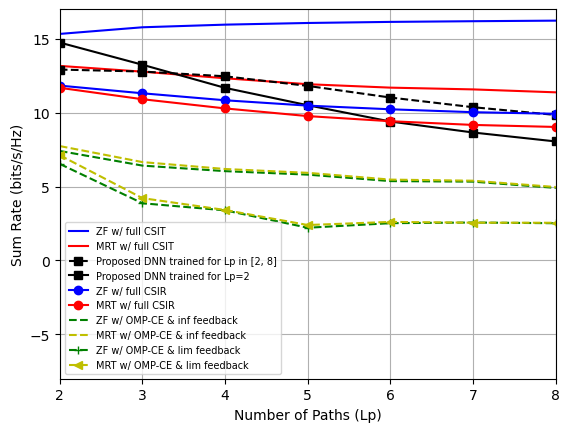

In [14]:
import matplotlib.pyplot as plt
import pickle

ZF_w_full_CSIT = [15.323568344116211, 15.771842956542969, 15.950119972229004, 16.062725067138672, 16.13614273071289, 16.182323455810547, 16.220773696899414]
MRT_w_full_CSIT = [13.159282684326172, 12.769577980041504, 12.323843002319336, 11.920799255371094, 11.688884735107422, 11.56978988647461, 11.37178897857666]
with open("Proposed DNN trained Lp=[2, 8]", 'rb') as ff:
    DNN_Lp_2_8 = pickle.load(ff)
with open("Proposed DNN trained Lp_2", 'rb') as ff:
    DNN_LP_2 = pickle.load(ff)
with open('ZF full CSIR', 'rb') as ff:
    ZF_w_full_CSIR = pickle.load(ff)
with open('MRT full CSIR', 'rb') as ff:
    MRT_w_full_CSIR = pickle.load(ff)
with open("ZF OMP-CE inf", 'rb') as ff:
    ZF_w_OMP_inf = pickle.load(ff)    
with open("MRT OMP-CE inf", 'rb') as ff:
    MRT_w_OMP_inf = pickle.load(ff) 
with open("ZF OMP-CE lim", 'rb') as ff:
    ZF_w_OMP_lim = pickle.load(ff)    
with open("MRT OMP-CE lim", 'rb') as ff:
    MRT_w_OMP_lim = pickle.load(ff)
    
plt.plot(Lp, ZF_w_full_CSIT, '-b', label = 'ZF w/ full CSIT')
plt.plot(Lp, MRT_w_full_CSIT, '-r', label = 'MRT w/ full CSIT')
plt.plot(Lp, DNN_Lp_2_8, '--ks', label = 'Proposed DNN trained for Lp in [2, 8]')
plt.plot(Lp, DNN_LP_2, '-ks', label = 'Proposed DNN trained for Lp=2')
plt.plot(Lp, ZF_w_full_CSIR, '-bo', label = 'ZF w/ full CSIR')
plt.plot(Lp, MRT_w_full_CSIR, '-ro', label = 'MRT w/ full CSIR')
plt.plot(Lp, ZF_w_OMP_inf, '--g', label = 'ZF w/ OMP-CE & inf feedback')
plt.plot(Lp, MRT_w_OMP_inf, '--y', label = 'MRT w/ OMP-CE & inf feedback')
plt.plot(Lp, ZF_w_OMP_lim, '--g+', label = 'ZF w/ OMP-CE & lim feedback')
plt.plot(Lp, MRT_w_OMP_lim, '--y<', label = 'MRT w/ OMP-CE & lim feedback')

plt.xlabel('Number of Paths (Lp)')
plt.xlim([2,8])
plt.ylabel('Sum Rate (bits/s/Hz)')
plt.ylim([-8,17])
plt.legend(loc='best', fontsize='7')
plt.grid()
plt.show()

In [19]:
with open("Proposed DNN trained Lp=[2, 8]", 'wb') as ff:
    pickle.dump(DNN_Lp_2_8, ff)